In [2]:
import os
import glob
import pandas as pd

In [2]:
import os
import glob
import pandas as pd

# Define o diretório contendo os arquivos Parquet
directory = 'datasets/ts_ndt'

# Lista para armazenar os DataFrames individuais
dfs = []

# Itera sobre todos os arquivos Parquet no diretório
for file in glob.glob(os.path.join(directory, "*.parquet")):
    # Extrai o nome do arquivo e remove a extensão
    base_name = os.path.basename(file)                # Ex: "cliente_servidor.com_extra.parquet"
    name_without_ext = os.path.splitext(base_name)[0]   # Ex: "cliente_servidor.com_extra"
    
    # Divide o nome no primeiro underscore para separar cliente e servidor
    # Assim, 'cliente' é a parte antes do primeiro "_" e 'servidor' é o restante
    client, server = name_without_ext.split('_', 1)
    
    # Lê o arquivo Parquet e adiciona as colunas 'client' e 'server'
    df = pd.read_parquet(file)
    df['client'] = client
    df['server'] = server
    dfs.append(df)

# Concatena todos os DataFrames em um único DataFrame
all_data = pd.concat(dfs, ignore_index=True)

# Seleciona as colunas numéricas, que correspondem às métricas
metrics_columns = all_data.select_dtypes(include='number').columns.tolist()

# Remove as colunas de agrupamento, caso por acaso estejam na lista
for col in ['client', 'server']:
    if col in metrics_columns:
        metrics_columns.remove(col)

# Cálculo das estatísticas para cada cliente
client_stats = (
    all_data
    .groupby("client")[metrics_columns]
    .agg(["mean", "std"])
    .reset_index()
)

# Cálculo das estatísticas para cada servidor
server_stats = (
    all_data
    .groupby("server")[metrics_columns]
    .agg(["mean", "std"])
    .reset_index()
)

# Exibe os DataFrames com as estatísticas calculadas
print("Estatísticas por Cliente:")
print(client_stats)

print("\nEstatísticas por Servidor:")
print(server_stats)


Estatísticas por Cliente:
      client rtt_download            throughput_download              \
                     mean        std                mean         std   
0   client01     9.669518   5.313520          515.127084   23.925863   
1   client02    13.917631   4.125960          586.034211   23.835895   
2   client03    52.746522  74.159755          592.675817  213.083369   
3   client04     9.736546   5.602429          741.381987  134.824215   
4   client05    24.100288  24.381113          567.069542  166.571677   
5   client06    44.050972  49.884659          629.080750  331.805103   
6   client07    29.890629  37.010311          712.972492  277.812186   
7   client08    35.674549  36.145701          649.097691  244.206697   
8   client09    28.548239  35.627153          718.562621  271.749191   
9   client10    32.343269  36.864353          739.954085  249.246338   
10  client11    31.369263  34.217914          705.366589  218.816884   
11  client12    31.312221  37.826034  

In [3]:
# Renomeia as colunas de agrupamento para um identificador comum e adiciona uma coluna para indicar o grupo
client_stats = client_stats.rename(columns={'client': 'id'})
client_stats['group'] = 'client'

server_stats = server_stats.rename(columns={'server': 'id'})
server_stats['group'] = 'server'

# Junta os DataFrames de clientes e servidores em um único DataFrame
combined_stats = pd.concat([client_stats, server_stats], ignore_index=True)

# Exibe o DataFrame combinado com as estatísticas agregadas
print("Estatísticas agregadas:")
print(combined_stats)

Estatísticas agregadas:
          id rtt_download            throughput_download              \
                     mean        std                mean         std   
0   client01     9.669518   5.313520          515.127084   23.925863   
1   client02    13.917631   4.125960          586.034211   23.835895   
2   client03    52.746522  74.159755          592.675817  213.083369   
3   client04     9.736546   5.602429          741.381987  134.824215   
4   client05    24.100288  24.381113          567.069542  166.571677   
5   client06    44.050972  49.884659          629.080750  331.805103   
6   client07    29.890629  37.010311          712.972492  277.812186   
7   client08    35.674549  36.145701          649.097691  244.206697   
8   client09    28.548239  35.627153          718.562621  271.749191   
9   client10    32.343269  36.864353          739.954085  249.246338   
10  client11    31.369263  34.217914          705.366589  218.816884   
11  client12    31.312221  37.826034    

In [4]:
#combined_stats.to_csv('general_statistics.csv', index=False)

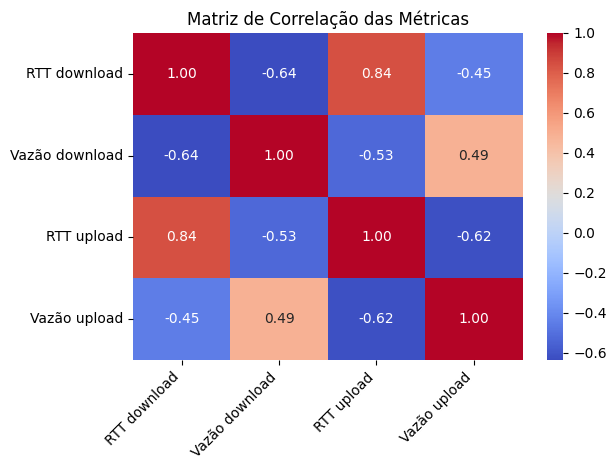

In [25]:
# Plotar a matriz de correlação das métricas
import matplotlib.pyplot as plt
import seaborn as sns

# Calcula a matriz de correlação
correlation_matrix = all_data[metrics_columns].corr()
# Configura o tamanho da figura
#plt.figure(figsize=(8, 8))
# Cria o heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
#labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=['RTT download', 'Vazão download', 'RTT upload', 'Vazão upload'] , rotation=45, ha='right')
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=['RTT download', 'Vazão download', 'RTT upload', 'Vazão upload'], rotation=0)
plt.title('Matriz de Correlação das Métricas')
plt.tight_layout()
plt.show()

In [40]:
import numpy as np

feature = 'rtt_upload'
survival_data = []
cp_dir = f'datasets/ts_ndt_cp/'

for file in os.listdir(cp_dir):
    if file.endswith(".parquet"):
        df = pd.read_parquet(os.path.join(cp_dir, file))
        client, site = file.split('.')[0].split('_', 1)

        # Ordenar pelo timestamp
        df.sort_values(by='timestamp', inplace=True)

        # Identificar changepoints
        changepoint_column = f'{feature}_cp'

        if changepoint_column not in df.columns:
            print(f"Changepoint column '{changepoint_column}' not found in {file}. Skipping.")
            continue
        changepoint_indices = df.index[df[changepoint_column] == 1].tolist()

        # Calcular gaps de tempo
        df['time_diff'] = df['timestamp'].diff().dt.total_seconds() / (60 * 60 * 24)
        large_gaps = df.index[df['time_diff'] > 3].tolist()
        split_indices = [0]

        # Adicionar os índices antes e depois dos gaps como split indices
        for gap in large_gaps:
            if gap - 1 >= 0:
                split_indices.append(gap - 1)  # Antes do gap
            split_indices.append(gap)  # Depois do gap
        split_indices.append(len(df) - 1)

        split_indices = sorted(set(split_indices))  # Garantir que os índices são únicos e ordenados

        # Iterar entre as subdivisões
        for i, (start, end) in enumerate(zip(split_indices[:-1], split_indices[1:])):
            sub_df = df.iloc[start:end + 1]  # Incluir o índice final
            if len(sub_df) < 2:
                continue

            # Identificar changepoints nesta subsequência
            sub_changepoints = [cp for cp in changepoint_indices if start <= cp <= end]
            all_points = [start] + sub_changepoints + [end]

            # Iterar sobre os intervalos entre todos os pontos
            for j in range(len(all_points) - 1):
                start_idx = all_points[j]
                end_idx = all_points[j + 1]
                if start_idx >= len(df) or end_idx >= len(df) or start_idx >= end_idx:
                    continue

                start_time = df['timestamp'].iloc[start_idx]
                end_time = df['timestamp'].iloc[end_idx]
                duration = (end_time - start_time).total_seconds() / (60 * 60 * 24)

                initial_values = df.iloc[start_idx].to_dict()
                
                # Buscar o primeiro valor válido para cada variável
                throughput_download_local_mean = initial_values.get('throughput_download_local_mean', np.nan)
                if pd.isna(throughput_download_local_mean):
                    throughput_download_local_mean = df['throughput_download_local_mean'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['throughput_download_local_mean'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                throughput_upload_local_mean = initial_values.get('throughput_upload_local_mean', np.nan)
                if pd.isna(throughput_upload_local_mean):
                    throughput_upload_local_mean = df['throughput_upload_local_mean'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['throughput_upload_local_mean'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                rtt_download_local_mean = initial_values.get('rtt_download_local_mean', np.nan)
                if pd.isna(rtt_download_local_mean):
                    rtt_download_local_mean = df['rtt_download_local_mean'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['rtt_download_local_mean'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                rtt_upload_local_mean = initial_values.get('rtt_upload_local_mean', np.nan)
                if pd.isna(rtt_upload_local_mean):
                    rtt_upload_local_mean = df['rtt_upload_local_mean'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['rtt_upload_local_mean'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                throughput_download_local_std = initial_values.get('throughput_download_local_std', np.nan)
                if pd.isna(throughput_download_local_std):
                    throughput_download_local_std = df['throughput_download_local_std'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['throughput_download_local_std'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                throughput_upload_local_std = initial_values.get('throughput_upload_local_std', np.nan)
                if pd.isna(throughput_upload_local_std):
                    throughput_upload_local_std = df['throughput_upload_local_std'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['throughput_upload_local_std'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                rtt_download_local_std = initial_values.get('rtt_download_local_std', np.nan)
                if pd.isna(rtt_download_local_std):
                    rtt_download_local_std = df['rtt_download_local_std'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['rtt_download_local_std'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                rtt_upload_local_std = initial_values.get('rtt_upload_local_std', np.nan)
                if pd.isna(rtt_upload_local_std):
                    rtt_upload_local_std = df['rtt_upload_local_std'].iloc[start_idx:end_idx+1].dropna().values[0] if not df['rtt_upload_local_std'].iloc[start_idx:end_idx+1].dropna().empty else np.nan

                if start_idx in changepoint_indices and end_idx in changepoint_indices:
                    event = 1
                elif start_idx not in changepoint_indices and end_idx in changepoint_indices:
                    event = 2
                elif start_idx in changepoint_indices and end_idx not in changepoint_indices:
                    event = 3
                else:
                    event = 4

                survival_data.append({
                    'client': client,
                    'site': site,
                    'timestamp_start': start_time,
                    'timestamp_end': end_time,
                    'time': duration,
                    'throughput_download_mean': throughput_download_local_mean,
                    'rtt_download_mean': rtt_download_local_mean,
                    'throughput_upload_mean': throughput_upload_local_mean,
                    'rtt_upload_mean': rtt_upload_local_mean,
                    'throughput_download_std': throughput_download_local_std,
                    'rtt_download_std': rtt_download_local_std,
                    'throughput_upload_std': throughput_upload_local_std,
                    'rtt_upload_std': rtt_upload_local_std,
                    'event': event
                })

# Converter para DataFrame
survival_df = pd.DataFrame(survival_data)
survival_df = pd.get_dummies(survival_df, columns=['client', 'site'])

for col in survival_df.columns:
    if col.startswith('client_') or col.startswith('site_'):
        survival_df[col] = survival_df[col].astype(int)

In [41]:
survival_df.event.value_counts()

4    97
1    44
2    27
3    27
Name: event, dtype: int64

In [3]:
surv_df = pd.read_csv('output_files/dataset_survival_throughput_download.csv')

In [4]:
# Métricas agregadas por cluster
surv_df_agg = surv_df.groupby('cluster').agg({
    'time': ['mean', 'std', 'median'],
    'throughput_download_mean': ['mean', 'std', 'median'],
    'rtt_download_mean': ['mean', 'std', 'median'],
    'throughput_upload_mean': ['mean', 'std', 'median'],
    'rtt_upload_mean': ['mean', 'std', 'median'],
    'event': ['sum', 'mean']
}).reset_index()

In [5]:
surv_df_agg

cluster       time                       throughput_download_mean  \
                mean        std     median                     mean   
0       0  10.643587  13.827890   6.654965               452.062917   
1       1  24.292145  22.456363  19.616082               632.541577   

                          rtt_download_mean                        \
          std      median              mean        std     median   
0  265.192241  554.085900         59.591389  63.278060  19.105361   
1  196.715485  652.493671         16.036139   4.375823  15.370875   

  throughput_upload_mean                         rtt_upload_mean             \
                    mean         std      median            mean        std   
0             429.256693  285.496715  299.924750       60.643740  65.518823   
1             684.292094  226.741879  792.917982       18.866753  19.512573   

            event            
     median   sum      mean  
0  18.60950    76  0.737864  
1  13.18217    12  0.077922

In [1]:
import pandas as pd
import os
from collections import defaultdict

def calculate_cluster_statistics_from_raw_data(intervals_path, raw_data_folder):
    """
    Calcula e imprime as características estatísticas dos clusters agregando
    os dados brutos das séries temporais.

    Esta função implementa a metodologia da dissertação ao ler primeiro os
    intervalos rotulados de um ficheiro CSV. Em seguida, itera sobre cada intervalo,
    carrega os dados brutos da série temporal correspondente de um ficheiro Parquet, filtra
    as medições dentro dos timestamps do intervalo e agrega-as por cluster.
    Finalmente, calcula as estatísticas sobre estas medições brutas agregadas.

    Args:
        intervals_path (str): O caminho para o ficheiro CSV do dataset de sobrevivência que contém
                              as definições dos intervalos e os rótulos dos clusters.
        raw_data_folder (str): O caminho para a pasta que contém os ficheiros Parquet
                               das séries temporais brutas.
    """
    try:
        df_intervals = pd.read_csv(intervals_path)
    except FileNotFoundError:
        print(f"Erro: O ficheiro de intervalos {intervals_path} não foi encontrado.")
        return

    # --- Parte 1: Calcular estatísticas que dependem apenas do ficheiro de intervalos ---
    results = {}
    grouped_intervals = df_intervals.groupby('cluster')

    for cluster_id, cluster_df in grouped_intervals:
        results[cluster_id] = {
            'Nº de intervalos': len(cluster_df),
            'Duração (dias)': {
                'Média': cluster_df['time'].mean(),
                'Mediana': cluster_df['time'].median(),
                'Desvio padrão': cluster_df['time'].std()
            },
            'Freq. relativa de eventos': cluster_df['event'].mean(),
            'Probabilidades de sobrevivência': {
                f'{t} dias': (cluster_df['time'] > t).mean()
                for t in [1, 7, 15, 30, 60, 90]
            },
            'Métricas': {}
        }

    # --- Parte 2: Agregar dados brutos das séries temporais ---
    # Estrutura para armazenar todas as medições brutas por cluster e por métrica
    raw_metrics_agg = {
        0: defaultdict(list),
        1: defaultdict(list)
    }
    
    # Colunas de métricas brutas a serem extraídas dos ficheiros Parquet
    metric_columns = {
        'Vazão download (Mbps)': 'throughput_download',
        'Vazão upload (Mbps)': 'throughput_upload',
        'RTT download (ms)': 'rtt_download',
        'RTT upload (ms)': 'rtt_upload'
    }
    
    # Dicionário para guardar os dataframes já carregados e evitar leituras repetidas
    loaded_parquet_files = {}

    print("A processar intervalos e agregar dados brutos...")
    for _, row in df_intervals.iterrows():
        client = row['client']
        server = row['site']
        pair = f"{client}_{server}"
        
        try:
            # Carregar o ficheiro parquet apenas uma vez por par cliente-servidor
            if pair not in loaded_parquet_files:
                parquet_path = os.path.join(raw_data_folder, f"{pair}.parquet")
                df_ts = pd.read_parquet(parquet_path)
                df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
                loaded_parquet_files[pair] = df_ts
            
            df_ts = loaded_parquet_files[pair]
            
            # Filtrar medições brutas dentro do intervalo de tempo
            start_time = row['timestamp_start']
            end_time = row['timestamp_end']
            cluster_id = row['cluster']
            
            mask = (df_ts['timestamp'] >= start_time) & (df_ts['timestamp'] <= end_time)
            raw_chunk = df_ts.loc[mask]
            
            # Adicionar os dados brutos ao agregador do cluster correspondente
            for metric_name_display, metric_col_raw in metric_columns.items():
                raw_metrics_agg[cluster_id][metric_name_display].extend(raw_chunk[metric_col_raw].dropna().tolist())

        except FileNotFoundError:
            # Adicionar o par ao dicionário com None para não tentar novamente
            if pair not in loaded_parquet_files:
                 print(f"Aviso: Ficheiro parquet não encontrado para o par {pair}. Saltando intervalos associados.")
                 loaded_parquet_files[pair] = None
        except Exception as e:
            print(f"Erro ao processar o ficheiro para o par {pair}: {e}")
            loaded_parquet_files[pair] = None


    # --- Parte 3: Calcular estatísticas a partir dos dados brutos agregados ---
    print("A calcular as estatísticas finais...")
    for cluster_id in [0, 1]:
        for metric_name in metric_columns.keys():
            raw_values = pd.Series(raw_metrics_agg[cluster_id][metric_name])
            if not raw_values.empty:
                results[cluster_id]['Métricas'][metric_name] = {
                    'Média': raw_values.mean(),
                    'Mediana': raw_values.median(),
                    'Desvio padrão': raw_values.std()
                }
            else:
                 results[cluster_id]['Métricas'][metric_name] = {
                    'Média': float('nan'), 'Mediana': float('nan'), 'Desvio padrão': float('nan')
                }


    # --- Parte 4: Imprimir a tabela final formatada ---
    print("\n--- Características Estatísticas dos Clusters (baseado nas Séries Temporais Brutas) ---")
    header = f"{'Característica':<35} | {'Cluster 0':<15} | {'Cluster 1':<15}"
    print(header)
    print("-" * len(header))

    print(f"{'Nº de intervalos':<35} | {results[0]['Nº de intervalos']:<15} | {results[1]['Nº de intervalos']:<15}")
    print("\nDuração (dias)")
    for stat in ['Média', 'Mediana', 'Desvio padrão']:
        print(f"  {stat:<33} | {results[0]['Duração (dias)'][stat]:<15.2f} | {results[1]['Duração (dias)'][stat]:<15.2f}")

    print(f"\n{'Freq. relativa de eventos':<35} | {results[0]['Freq. relativa de eventos']:<15.3f} | {results[1]['Freq. relativa de eventos']:<15.3f}")

    print("\nProbabilidades de sobrevivência")
    for t_str, prob0 in results[0]['Probabilidades de sobrevivência'].items():
        prob1 = results[1]['Probabilidades de sobrevivência'][t_str]
        print(f"  {t_str:<33} | {prob0:<15.3f} | {prob1:<15.3f}")

    for metric_name in metric_columns.keys():
        print(f"\n{metric_name}")
        for stat in ['Média', 'Mediana', 'Desvio padrão']:
            val0 = results[0]['Métricas'][metric_name][stat]
            val1 = results[1]['Métricas'][metric_name][stat]
            print(f"  {stat:<33} | {val0:<15.2f} | {val1:<15.2f}")

# --- INSTRUÇÕES DE EXECUÇÃO ---
# 1. Certifique-se de que tem o pandas e o pyarrow instalados:
#    pip install pandas pyarrow
# 2. Coloque este script, o ficheiro 'dataset_survival_rtt_upload.csv' e a pasta 'datasets' na mesma diretoria.
# 3. A estrutura de pastas deve ser:
#    - seu_script.py
#    - dataset_survival_rtt_upload.csv
#    - datasets/
#      - ts_ndt_results/
#        - client01_gru03.parquet
#        - client02_rnp_sp.parquet
#        - ... (etc.)

# Executar a função
calculate_cluster_statistics_from_raw_data(
    'output_files/dataset_survival_rtt_upload.csv',
    'datasets/ts_ndt_results'
)

A processar intervalos e agregar dados brutos...
A calcular as estatísticas finais...

--- Características Estatísticas dos Clusters (baseado nas Séries Temporais Brutas) ---
Característica                      | Cluster 0       | Cluster 1      
-----------------------------------------------------------------------
Nº de intervalos                    | 62              | 133            

Duração (dias)
  Média                             | 10.55           | 31.45          
  Mediana                           | 4.39            | 28.98          
  Desvio padrão                     | 13.13           | 24.89          

Freq. relativa de eventos           | 0.645           | 0.030          

Probabilidades de sobrevivência
  1 dias                            | 0.903           | 1.000          
  7 dias                            | 0.452           | 0.774          
  15 dias                           | 0.226           | 0.647          
  30 dias                           | 0.081           |

In [3]:
import pandas as pd
from scipy import stats

def perform_welch_t_test(file_path, metric_column):
    """
    Carrega os dados dos clusters e realiza o teste t de Welch para uma métrica específica.

    Args:
        file_path (str): Caminho para o ficheiro CSV com os dados dos intervalos.
        metric_column (str): O nome da coluna da métrica a ser testada 
                             (ex: 'throughput_download_mean').
    """
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Erro: O ficheiro {file_path} não foi encontrado.")
        return

    # Separar os dados da métrica para cada cluster
    cluster0_data = df[df['cluster'] == 0][metric_column].dropna()
    cluster1_data = df[df['cluster'] == 1][metric_column].dropna()

    if cluster0_data.empty or cluster1_data.empty:
        print("Não há dados suficientes em um ou ambos os clusters para realizar o teste.")
        return

    # Realizar o teste t de Welch
    # O parâmetro `equal_var=False` é o que especifica o uso do teste de Welch
    t_stat, p_value = stats.ttest_ind(cluster0_data, cluster1_data, equal_var=False)

    print(f"--- Resultado do Teste t de Welch para a Métrica: {metric_column} ---")
    print(f"Estatística t: {t_stat:.4f}")
    print(f"P-valor: {p_value:.2e}") # Usando notação científica para p-valores pequenos

    # Interpretação do resultado
    alpha = 0.05
    if p_value < alpha:
        print(f"\nConclusão: Como o p-valor ({p_value:.2e}) é menor que {alpha}, rejeitamos a hipótese nula.")
        print("Existe uma diferença estatisticamente significativa entre as médias dos clusters 0 e 1 para esta métrica.")
    else:
        print(f"\nConclusão: Como o p-valor ({p_value:.2e}) é maior que {alpha}, não podemos rejeitar a hipótese nula.")
        print("Não há evidência de uma diferença estatisticamente significativa entre as médias dos clusters.")

# --- INSTRUÇÕES DE EXECUÇÃO ---
# 1. Certifique-se de que tem o pandas e o scipy instalados:
#    pip install pandas scipy
# 2. Coloque este script e o ficheiro 'dataset_survival_rtt_upload.csv' na mesma diretoria.
# 3. Execute o script.

# Exemplo de como executar para as métricas de interesse
perform_welch_t_test('output_files/dataset_survival_rtt_upload.csv', 'throughput_download_mean')
print("\n" + "="*70 + "\n")
perform_welch_t_test('output_files/dataset_survival_rtt_upload.csv', 'throughput_upload_mean')
print("\n" + "="*70 + "\n")
perform_welch_t_test('output_files/dataset_survival_rtt_upload.csv', 'rtt_download_mean')
print("\n" + "="*70 + "\n")
perform_welch_t_test('output_files/dataset_survival_rtt_upload.csv', 'rtt_upload_mean')
print("\n" + "="*70 + "\n")


--- Resultado do Teste t de Welch para a Métrica: throughput_download_mean ---
Estatística t: -11.3044
P-valor: 5.78e-19

Conclusão: Como o p-valor (5.78e-19) é menor que 0.05, rejeitamos a hipótese nula.
Existe uma diferença estatisticamente significativa entre as médias dos clusters 0 e 1 para esta métrica.


--- Resultado do Teste t de Welch para a Métrica: throughput_upload_mean ---
Estatística t: -10.3036
P-valor: 2.59e-18

Conclusão: Como o p-valor (2.59e-18) é menor que 0.05, rejeitamos a hipótese nula.
Existe uma diferença estatisticamente significativa entre as médias dos clusters 0 e 1 para esta métrica.


--- Resultado do Teste t de Welch para a Métrica: rtt_download_mean ---
Estatística t: 8.5827
P-valor: 3.03e-12

Conclusão: Como o p-valor (3.03e-12) é menor que 0.05, rejeitamos a hipótese nula.
Existe uma diferença estatisticamente significativa entre as médias dos clusters 0 e 1 para esta métrica.


--- Resultado do Teste t de Welch para a Métrica: rtt_upload_mean ---
Es

In [15]:
import pandas as pd
import numpy as np

coef_df = pd.read_csv('output_files/coefficients_throughput_download.csv')

In [16]:
coef_df.head()

,feature,coefficient,type
0,client01,0.832556,client
1,client02,-1.952059,client
2,client03,0.473496,client
3,client04,0.123275,client
4,client05,1.341431,client


In [17]:
# Excluir coluna type
coef_df = coef_df.drop(columns=['type'])

In [18]:
# Transformar em JSON
coef_df = coef_df.to_json(orient="records", indent=2)

In [19]:
print(coef_df)

[
  {
    "feature":"client01",
    "coefficient":0.8325555256
  },
  {
    "feature":"client02",
    "coefficient":-1.9520590967
  },
  {
    "feature":"client03",
    "coefficient":0.47349628
  },
  {
    "feature":"client04",
    "coefficient":0.123274743
  },
  {
    "feature":"client05",
    "coefficient":1.3414314327
  },
  {
    "feature":"client06",
    "coefficient":0.3746463827
  },
  {
    "feature":"client07",
    "coefficient":-1.7344425085
  },
  {
    "feature":"client08",
    "coefficient":-0.4008017327
  },
  {
    "feature":"client09",
    "coefficient":-0.3169876699
  },
  {
    "feature":"client10",
    "coefficient":-0.2823155657
  },
  {
    "feature":"client11",
    "coefficient":0.6814997914
  },
  {
    "feature":"client12",
    "coefficient":0.48601729
  },
  {
    "feature":"client13",
    "coefficient":-0.6060202457
  },
  {
    "feature":"client14",
    "coefficient":0.5455196667
  },
  {
    "feature":"client15",
    "coefficient":0.4047569824
  },
  {
   

In [12]:
# Criar coluna de odds ratios
coef_df['odds_ratio'] = coef_df['coefficient'].apply(lambda x: round(np.exp(x), 3))

In [1]:
coef_df

NameError: name 'coef_df' is not defined

In [15]:
import pandas as pd
import os
from collections import defaultdict

def calculate_aggregate_statistics(intervals_path, raw_data_folder):
    """
    Calcula a média e o desvio padrão gerais para as quatro métricas principais,
    agregados por cliente e por servidor, com base nos dados brutos das séries temporais.

    Args:
        intervals_path (str): O caminho para o ficheiro CSV do dataset de sobrevivência, usado para identificar
                              todos os pares únicos de cliente-servidor.
        raw_data_folder (str): O caminho para a pasta que contém os ficheiros Parquet
                               das séries temporais brutas.
    """
    try:
        df_intervals = pd.read_csv(intervals_path)
    except FileNotFoundError:
        print(f"Erro: O ficheiro de intervalos {intervals_path} não foi encontrado.")
        print("Por favor, certifique-se de que o ficheiro está no mesmo diretório que o script.")
        return

    # 1. Identificar pares únicos de cliente-servidor
    unique_pairs = df_intervals[['client', 'site']].drop_duplicates()

    # 2. Inicializar agregadores de dados
    client_data = defaultdict(lambda: defaultdict(list))
    server_data = defaultdict(lambda: defaultdict(list))
    
    metrics_to_process = [
        'throughput_download', 'throughput_upload', 
        'rtt_download', 'rtt_upload'
    ]

    print("A processar ficheiros Parquet e agregar dados brutos...")
    # 3. Iterar sobre os pares, carregar os dados e agregar
    for _, row in unique_pairs.iterrows():
        client = row['client']
        server = row['site']
        pair_filename = f"{client}_{server}.parquet"
        parquet_path = os.path.join(raw_data_folder, pair_filename)

        try:
            df_ts = pd.read_parquet(parquet_path)
            
            for metric in metrics_to_process:
                # Obter os dados brutos, removendo valores nulos
                raw_values = df_ts[metric].dropna().tolist()
                
                # Adicionar aos agregadores do cliente e do servidor
                client_data[client][metric].extend(raw_values)
                server_data[server][metric].extend(raw_values)

        except FileNotFoundError:
            print(f"Aviso: Ficheiro parquet não encontrado para o par {client}_{server}. A ignorar.")
        except Exception as e:
            print(f"Erro ao processar o ficheiro {pair_filename}: {e}")

    # 4. Calcular e apresentar estatísticas
    def print_stats_table(data_agg, entity_name):
        print(f"\n--- Estatísticas Agregadas por {entity_name} ---")
        
        # Cabeçalho dinâmico
        header = f"{entity_name:<15}"
        for metric in metrics_to_process:
            header += f" | {metric}_mean"
            header += f" | {metric}_std"
        print(header)
        print("-" * len(header))

        # Ordenar para uma visualização consistente
        sorted_keys = sorted(data_agg.keys())

        for key in sorted_keys:
            line = f"{key:<15}"
            for metric in metrics_to_process:
                values = data_agg[key][metric]
                if values:
                    series = pd.Series(values)
                    mean_val = series.mean()
                    std_val = series.std()
                    line += f" | {mean_val:<20.2f}"
                    line += f" | {std_val:<15.2f}"
                else:
                    line += f" | {'NaN':<20}"
                    line += f" | {'NaN':<15}"
            print(line)

    print_stats_table(client_data, "Cliente")
    print_stats_table(server_data, "Servidor")


# --- INSTRUÇÕES DE EXECUÇÃO ---
# 1. Certifique-se de que tem o pandas e o pyarrow instalados no seu ambiente Python:
#    pip install pandas pyarrow
# 2. Guarde este código num ficheiro Python (ex: `analise_agregada.py`).
# 3. Crie a seguinte estrutura de pastas e ficheiros no mesmo diretório:
#    - analise_agregada.py
#    - dataset_survival_rtt_upload.csv
#    - datasets/
#      - ts_ndt_results/
#        - client01_gru03.parquet
#        - client02_rnp_sp.parquet
#        - ... (e todos os outros ficheiros .parquet)
# 4. Execute o script a partir do seu terminal:
#    python analise_agregada.py

# Chamada da função principal
calculate_aggregate_statistics(
    'output_files/dataset_survival_rtt_upload.csv',
    'datasets/ts_ndt_results'
)

A processar ficheiros Parquet e agregar dados brutos...

--- Estatísticas Agregadas por Cliente ---
Cliente         | throughput_download_mean | throughput_download_std | throughput_upload_mean | throughput_upload_std | rtt_download_mean | rtt_download_std | rtt_upload_mean | rtt_upload_std
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
client01        | 515.13               | 23.93           | 254.75               | 28.09           | 9.67                 | 5.31            | 13.54                | 4.59           
client02        | 586.03               | 23.84           | 299.05               | 3.36            | 13.92                | 4.13            | 15.27                | 4.08           
client03        | 592.68               | 213.08          | 117.06               | 35.77           | 52.75                | 74.16           | 120.30         